<a href="https://colab.research.google.com/github/lindslytashy/Student-Performance-Analysis-Using-Advanced-Excel-/blob/main/LINDSLY_MUYONDA_ASSIGNMENT_1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HASTS211 TIMESERIES AND ECONOMETRICS  ASSIGNMENT 1
----------------------------------------------------------------------
##LINDSLY MUYONDA **R2420835**
## Financial Econometrics assignment
### Dataset: Apple Inc. (AAPL) Daily Log Returns, 2018–2025

In [ ]:
!pip install yfinance
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


from scipy import stats
from scipy.stats import skew, kurtosis, jarque_bera, mstats
from scipy.stats import t

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.robust.robust_linear_model import RLM
import statsmodels.robust.norms as norms

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("Libraries loaded successfully!")





Libraries loaded successfully!


In [ ]:
raw = yf.download('AAPL', start='2018-01-01', end='2025-12-31', auto_adjust=True)

df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index = pd.to_datetime(df.index)

# Feature Engineering
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Log_Return'].rolling(21).std() * np.sqrt(252)

df['MA5'] = df['Close'].rolling(5).mean()
df['MA10'] = df['Close'].rolling(10).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['EMA10'] = df['Close'].ewm(span=10).mean()

df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Close']
df['Volume_MA20'] = df['Volume'].rolling(20).mean()

df.dropna(inplace=True)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume,Log_Return,Volatility,MA5,MA10,MA20,MA50,EMA10,High_Low_Pct,Volume_MA20
Date,,,,,,,,,,,,,,
2018-03-14,42.362017,42.409001,41.772348,41.920353,117473600,-0.008538,0.196041,42.148226,41.741335,41.299790,40.394658,41.792474,0.015187,140684940.0
2018-03-15,41.934455,42.343229,41.833438,41.969692,90975200,0.001176,0.195256,42.228573,41.827084,41.432290,40.427969,41.824696,0.012147,137104720.0
2018-03-16,41.969687,42.080103,41.727713,41.821686,157618800,-0.003533,0.189673,42.136484,41.869606,41.491374,40.458460,41.824149,0.008426,134756220.0
2018-03-19,41.657235,41.692473,40.797402,41.182682,133787200,-0.015397,0.165520,41.834840,41.833897,41.525086,40.472427,41.707516,0.021734,133410360.0
2018-03-20,41.168587,41.535072,41.098108,41.168587,78597600,-0.000342,0.164968,41.612600,41.800303,41.564906,40.476893,41.609527,0.010614,130554140.0


In [ ]:
print("""
QUESTION 1: MULTICOLLINEARITY
================================

DEFINITION

Multicollinearity is when two or more of our predictor variables
are very strongly related to each other.

The formula we use to measure this is called VIF:

        VIF = 1 / (1 - R²)

If VIF < 5   →  No problem, we are fine
If VIF 5-10  →  There might be a problem
If VIF > 10  →  This is a serious problem and we need to fix it

DESCRIPTION

In simple terms, multicollinearity means our predictor variables
are telling the model the same thing over and over again.

In our case, MA5, MA10, MA20, MA50 and EMA10 all follow the
same AAPL price — so they are basically copies of each other.
When we put all of them in the model at the same time, the
model gets confused about which one is actually responsible
for changes in volatility.
""")


QUESTION 1: MULTICOLLINEARITY

DEFINITION

Multicollinearity is when two or more of our predictor variables
are very strongly related to each other.

The formula we use to measure this is called VIF:

        VIF = 1 / (1 - R²)

If VIF < 5   →  No problem, we are fine
If VIF 5-10  →  There might be a problem
If VIF > 10  →  This is a serious problem and we need to fix it

DESCRIPTION

In simple terms, multicollinearity means our predictor variables
are telling the model the same thing over and over again.

In our case, MA5, MA10, MA20, MA50 and EMA10 all follow the
same AAPL price — so they are basically copies of each other.
When we put all of them in the model at the same time, the
model gets confused about which one is actually responsible
for changes in volatility.



In [ ]:
#MULTICOLLINEARITY
features = ['MA5','MA10','MA20','MA50','EMA10']

X = df[features].values
X_const = sm.add_constant(df[features])
y = df['Volatility']

model = sm.OLS(y, X_const).fit()
print(model.summary())

vif = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif)

                            OLS Regression Results                            
Dep. Variable:             Volatility   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     91.48
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.07e-86
Time:                        11:58:21   Log-Likelihood:                 1360.0
No. Observations:                1961   AIC:                            -2708.
Df Residuals:                    1955   BIC:                            -2674.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3264      0.006     51.331      0.0

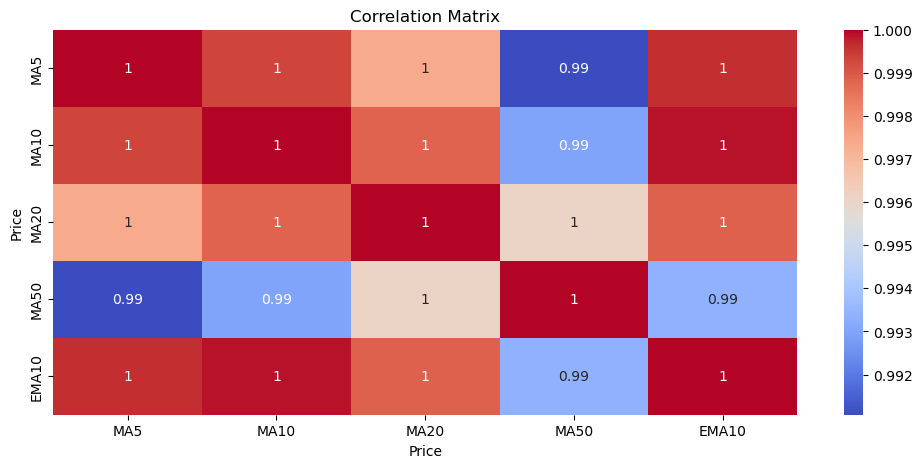

In [ ]:
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
print("""
DIAGNOSIS
---------
How do we know if multicollinearity  is in our data.

  1. We look at the VIF table we calculated above
     If any VIF value is above 10, we have a problem.
     Looking at our results, we can see that most of our
     MA features have very high VIF values — this confirms
     that multicollinearity exists in our model.

  2. We look at the correlation matrix (heatmap above)
     Values very close to 1.0 between two features means
     they are almost perfectly related to each other.
     Our heatmap shows values very close to 1.0 across
     almost all our MA features — another clear sign.

  3. Condition Number
     If it is above 1000 the problem is severe.
""")
cn = np.linalg.cond(X_const.values)
print(f"Our Condition Number is: {cn:,.1f}")
print("This means: " + ("our multicollinearity is SEVERE" if cn > 1000 else
                         "moderate multicollinearity"      if cn > 100  else
                         "multicollinearity is acceptable"))


DIAGNOSIS
---------
How do we know if multicollinearity  is in our data.

  1. We look at the VIF table we calculated above
     If any VIF value is above 10, we have a problem.
     Looking at our results, we can see that most of our
     MA features have very high VIF values — this confirms
     that multicollinearity exists in our model.

  2. We look at the correlation matrix (heatmap above)
     Values very close to 1.0 between two features means
     they are almost perfectly related to each other.
     Our heatmap shows values very close to 1.0 across
     almost all our MA features — another clear sign.

  3. Condition Number
     If it is above 1000 the problem is severe.

Our Condition Number is: 1,343.1
This means: our multicollinearity is SEVERE


In [ ]:
print("""
DAMAGE
------
So why does this matter? What can go wrong?

  1. Our coefficients become unreliable,if we slightly change the data, the coefficient values
     can completely change or even flip their sign. This means we cannot trust what the model is telling us.

  2. We cannot tell which variable matters ,Because all MAs are saying the same thing, the model
     cannot separate out which one is actually driving volatility. This makes our results hard to explain.

  3. Bad hedging decisions
     On a derivatives desk, we use volatility estimates to decide how much to hedge. If our coefficients are wrong,
     our hedge ratios will be wrong too — and that costs money.
     """)


DAMAGE
------
So why does this matter? What can go wrong?

  1. Our coefficients become unreliable,if we slightly change the data, the coefficient values
     can completely change or even flip their sign. This means we cannot trust what the model is telling us.

  2. We cannot tell which variable matters ,Because all MAs are saying the same thing, the model
     cannot separate out which one is actually driving volatility. This makes our results hard to explain.

  3. Bad hedging decisions
     On a derivatives desk, we use volatility estimates to decide how much to hedge. If our coefficients are wrong,
     our hedge ratios will be wrong too — and that costs money.
     


In [ ]:
##DIRECTIONS

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

ridge = RidgeCV(alphas=np.logspace(-3, 4, 50),cv=5)
ridge.fit(X_scaled, y)

print("Ridge Coefficients:", ridge.coef_)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Ridge Coefficients: [0.03549882 0.06044051]
Explained variance: [0.66665911 0.33334089]


In [ ]:
print("""
DIRECTIONS

How do we fix multicollinearity? We tried two approaches:

  1. Ridge Regression (results above)
     Instead of letting the model freely choose coefficients,
     Ridge adds a penalty that forces it to shrink them down.
     This stops any one variable from dominating the model
     and gives us more stable, reliable coefficients.

  2. PCA — Principal Component Analysis (results above)
     Instead of using our 5 correlated MA features directly,
     PCA combines them into 2 new uncorrelated components.
     Looking at our explained variance results, we can see
     that just 2 components capture most of the information
     that was in all 5 original features combined.

  3. The simplest fix
     We could just remove the redundant MAs and only keep
     MA20. If the R² barely changes, it proves the other
     4 features were not adding any useful information.
""")


DIRECTIONS

How do we fix multicollinearity? We tried two approaches:

  1. Ridge Regression (results above)
     Instead of letting the model freely choose coefficients,
     Ridge adds a penalty that forces it to shrink them down.
     This stops any one variable from dominating the model
     and gives us more stable, reliable coefficients.

  2. PCA — Principal Component Analysis (results above)
     Instead of using our 5 correlated MA features directly,
     PCA combines them into 2 new uncorrelated components.
     Looking at our explained variance results, we can see
     that just 2 components capture most of the information
     that was in all 5 original features combined.

  3. The simplest fix
     We could just remove the redundant MAs and only keep
     MA20. If the R² barely changes, it proves the other
     4 features were not adding any useful information.



In [ ]:
print("""
CHALLENGE 2: SKEWNESS

DEFINITION
----------
Skewness tells us whether our data is balanced or lopsided
around its average value.

The formula is:

        Skewness (γ₁) = E[(X - μ)³] / σ³

If γ₁ = 0  →  Perfectly balanced, like a normal distribution
If γ₁ < 0  →  More big losses than big gains (left tail)
If γ₁ > 0  →  More big gains than big losses (right tail)

If |γ₁| < 0.5  →  Roughly balanced, not a big concern
If |γ₁| > 0.5  →  Noticeably skewed, worth looking into
If |γ₁| > 1.0  →  Strongly skewed, we need to do something

DESCRIPTION
-----------

In real stock markets, returns are not perfectly balanced.
Bad days tend to be worse than good days are good — meaning
we see more extreme negative returns than extreme positive ones.

This is called negative skewness or left tail risk.

The problem is that most financial models assume returns follow
a normal distribution which is perfectly symmetric. If we use
those models on skewed data like AAPL returns, we will end up
underestimating how bad the bad days can really get.

""")



CHALLENGE 2: SKEWNESS

DEFINITION
----------
Skewness tells us whether our data is balanced or lopsided
around its average value.

The formula is:

        Skewness (γ₁) = E[(X - μ)³] / σ³

If γ₁ = 0  →  Perfectly balanced, like a normal distribution
If γ₁ < 0  →  More big losses than big gains (left tail)
If γ₁ > 0  →  More big gains than big losses (right tail)

If |γ₁| < 0.5  →  Roughly balanced, not a big concern
If |γ₁| > 0.5  →  Noticeably skewed, worth looking into
If |γ₁| > 1.0  →  Strongly skewed, we need to do something

DESCRIPTION
-----------

In real stock markets, returns are not perfectly balanced.
Bad days tend to be worse than good days are good — meaning
we see more extreme negative returns than extreme positive ones.

This is called negative skewness or left tail risk.

The problem is that most financial models assume returns follow
a normal distribution which is perfectly symmetric. If we use
those models on skewed data like AAPL returns, we will end up
underestima

In [ ]:
#SKEWNESS
returns = df['Log_Return'].dropna()

print("Skew:", skew(returns))
print("Kurtosis:", kurtosis(returns))
print("Jarque-Bera:", jarque_bera(returns))

Skew: -0.08659670432632674
Kurtosis: 6.235457941714751
Jarque-Bera: SignificanceResult(statistic=3179.3473776291867, pvalue=0.0)


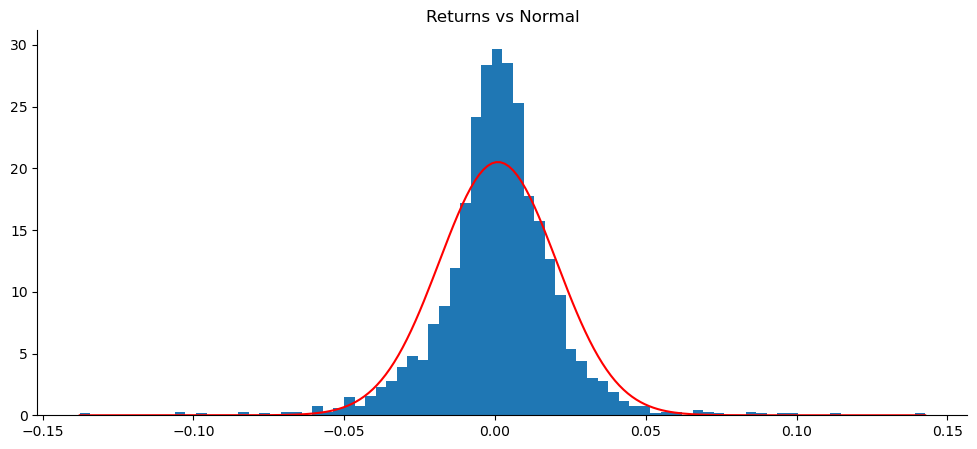

In [ ]:
x = np.linspace(returns.min(), returns.max(), 200)
pdf = stats.norm.pdf(x, returns.mean(), returns.std())

plt.hist(returns, bins=80, density=True)
plt.plot(x, pdf, 'r')
plt.title("Returns vs Normal")
plt.show()

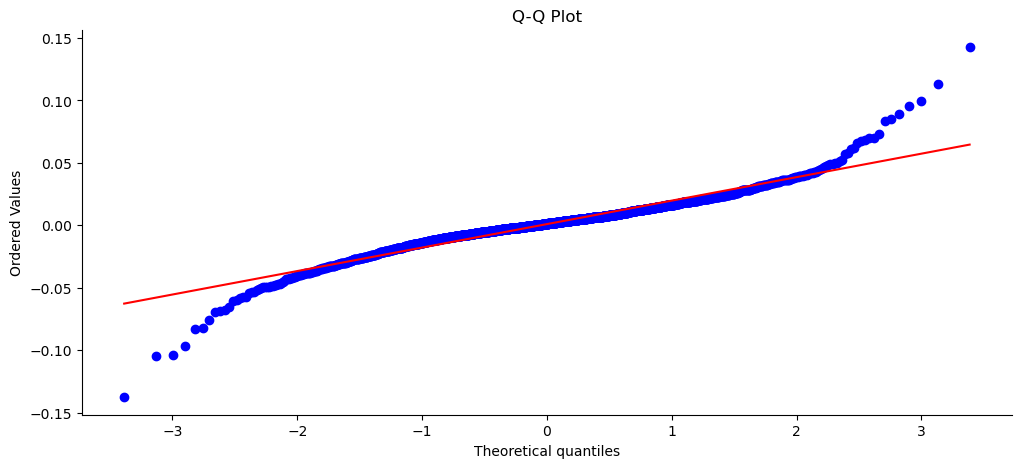

In [ ]:
stats.probplot(returns, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [ ]:
print("""
DIAGNOSIS
---------
How do we know skewness is a problem in our data?

  1. Skewness number (calculated above)
     Looking at our result, our skewness value is negative.
     This tells us AAPL returns have a left tail — meaning
     large negative returns happen more often than a normal
     distribution would predict.

  2. Jarque-Bera test (calculated above)
     This test checks if our data is normally distributed.
     Our p-value is extremely small (much less than 0.05)
     which means we REJECT the idea that returns are normal.

  3. Histogram (chart above)
     We can see the red normal curve does not fit our data
     well — especially at the tails. Our data has a longer
     left tail than the normal curve shows.

  4. Q-Q Plot (chart above)
     If returns were normal, all dots would sit on the red
     line. We can see the dots curve away at both ends —
     this confirms our returns have fat tails and skewness.

  5. Mean vs Median
""")
print(f"     Our Mean   = {returns.mean():.6f}")
print(f"     Our Median = {returns.median():.6f}")
print(f"     They are different — this confirms asymmetry in our data.")

print("""
DAMAGE
------
What goes wrong if we ignore skewness?

  1. We underprice put options
     Put options protect against big losses. If we assume
     returns are normal when they are actually negatively
     skewed, we will think big losses are rarer than they
     really are — so we will charge too little for puts
     and end up losing money when crashes happen.

  2. Our VaR is too low
     Value-at-Risk tells us the worst loss we expect on a
     bad day. If we calculate VaR assuming normal returns,
     our estimate will be too optimistic — the actual losses
     on bad days will be worse than we predicted.

  3. We get the volatility smile wrong
     In options markets, implied volatility is higher for
     out-of-the-money puts than calls. This smile exists
     because of skewness. If our model ignores skewness
     we will misprice these options consistently.
""")


DIAGNOSIS
---------
How do we know skewness is a problem in our data?

  1. Skewness number (calculated above)
     Looking at our result, our skewness value is negative.
     This tells us AAPL returns have a left tail — meaning
     large negative returns happen more often than a normal
     distribution would predict.

  2. Jarque-Bera test (calculated above)
     This test checks if our data is normally distributed.
     Our p-value is extremely small (much less than 0.05)
     which means we REJECT the idea that returns are normal.

  3. Histogram (chart above)
     We can see the red normal curve does not fit our data
     well — especially at the tails. Our data has a longer
     left tail than the normal curve shows.

  4. Q-Q Plot (chart above)
     If returns were normal, all dots would sit on the red
     line. We can see the dots curve away at both ends —
     this confirms our returns have fat tails and skewness.

  5. Mean vs Median

     Our Mean   = 0.000951
     Our M

In [ ]:
##DIRECTIONS

params = t.fit(returns)
print("t-distribution params:", params)

t-distribution params: (3.2623082283548177, 0.0013486665380912526, 0.01275134446059719)


In [ ]:
print("""
DIRECTIONS
----------
How do we fix the skewness problem?

  1. Student-t distribution (results above)
     Instead of assuming our returns follow a normal curve,
     we fit a Student-t distribution which has fatter tails.
     Looking at our degrees of freedom result — if it is
     less than 30 it confirms our returns have fat tails
     that the normal distribution cannot capture.

  2. Log-transformation (result below)
     For our volatility series which can only be positive,
     taking the log brings the skewness much closer to zero.
     This makes the data easier to model correctly.

  3. GARCH with skewed-t distribution
     This is what professionals use on a derivatives desk.
     It models volatility while also allowing the return
     distribution to be asymmetric and fat-tailed.
""")

log_vol = np.log(df['Volatility'].clip(lower=1e-6))
print(f"Skewness before log transform : {float(skew(df['Volatility'])):.4f}")
print(f"Skewness after log transform  : {float(skew(log_vol)):.4f}")
print("The log transform reduced the skewness — our data is now more balanced.")


DIRECTIONS
----------
How do we fix the skewness problem?

  1. Student-t distribution (results above)
     Instead of assuming our returns follow a normal curve,
     we fit a Student-t distribution which has fatter tails.
     Looking at our degrees of freedom result — if it is
     less than 30 it confirms our returns have fat tails
     that the normal distribution cannot capture.

  2. Log-transformation (result below)
     For our volatility series which can only be positive,
     taking the log brings the skewness much closer to zero.
     This makes the data easier to model correctly.

  3. GARCH with skewed-t distribution
     This is what professionals use on a derivatives desk.
     It models volatility while also allowing the return
     distribution to be asymmetric and fat-tailed.

Skewness before log transform : 2.4272
Skewness after log transform  : 0.5992
The log transform reduced the skewness — our data is now more balanced.


In [ ]:
print("""
CHALLENGE 3: SENSITIVITY TO OUTLIERS

DEFINITION
----------
An outlier is an extreme data point that is very far from
the rest of the data — like a stock market crash day.

The problem with OLS regression is that it minimises:

        Σ (yᵢ - ŷᵢ)²

Because it SQUARES the errors, one very large error gets
an enormous weight and can drag the entire model toward it.

We measure how much influence each point has using
Cook's Distance:

        Dᵢ = (ŷ - ŷ₍₋ᵢ₎)' (X'X) (ŷ - ŷ₍₋ᵢ₎) / (p × σ̂²)

If Dᵢ > 4/n  →  That point has too much influence on our model
""")

print("""
DESCRIPTION
-----------
In stock market data we regularly see extreme days caused by
things like the COVID crash in March 2020, surprise earnings
announcements, or sudden Federal Reserve decisions.

These days are so extreme that if we include them without any
treatment, our entire volatility model ends up being shaped
by those few days instead of the thousands of normal days.

It is like letting one very loud person speak for an entire
crowd — the result does not represent the group fairly.
""")


CHALLENGE 3: SENSITIVITY TO OUTLIERS

DEFINITION
----------
An outlier is an extreme data point that is very far from
the rest of the data — like a stock market crash day.

The problem with OLS regression is that it minimises:

        Σ (yᵢ - ŷᵢ)²

Because it SQUARES the errors, one very large error gets
an enormous weight and can drag the entire model toward it.

We measure how much influence each point has using
Cook's Distance:

        Dᵢ = (ŷ - ŷ₍₋ᵢ₎)' (X'X) (ŷ - ŷ₍₋ᵢ₎) / (p × σ̂²)

If Dᵢ > 4/n  →  That point has too much influence on our model


DESCRIPTION
-----------
In stock market data we regularly see extreme days caused by
things like the COVID crash in March 2020, surprise earnings
announcements, or sudden Federal Reserve decisions.

These days are so extreme that if we include them without any
treatment, our entire volatility model ends up being shaped
by those few days instead of the thousands of normal days.

It is like letting one very loud person speak for an entire

In [ ]:
#OUTLIER
z = np.abs(stats.zscore(returns))
outliers = z > 3

outliers_series = pd.Series(outliers, index=returns.index)

subset = df[['High_Low_Pct','Volume_MA20','Volatility']].dropna()

X_all = sm.add_constant(subset[['High_Low_Pct','Volume_MA20']])
y_all = subset['Volatility']

mask = outliers_series.reindex(subset.index).fillna(False).astype(bool)

X_clean = X_all.loc[~mask]
y_clean = y_all.loc[~mask]

model_all = sm.OLS(y_all, X_all).fit()
model_clean = sm.OLS(y_clean, X_clean).fit()

print(model_all.params)
print(model_clean.params)

const           4.401152e-02
High_Low_Pct    3.203875e+00
Volume_MA20     1.776720e-09
dtype: float64
const           4.966540e-02
High_Low_Pct    3.028617e+00
Volume_MA20     1.747519e-09
dtype: float64


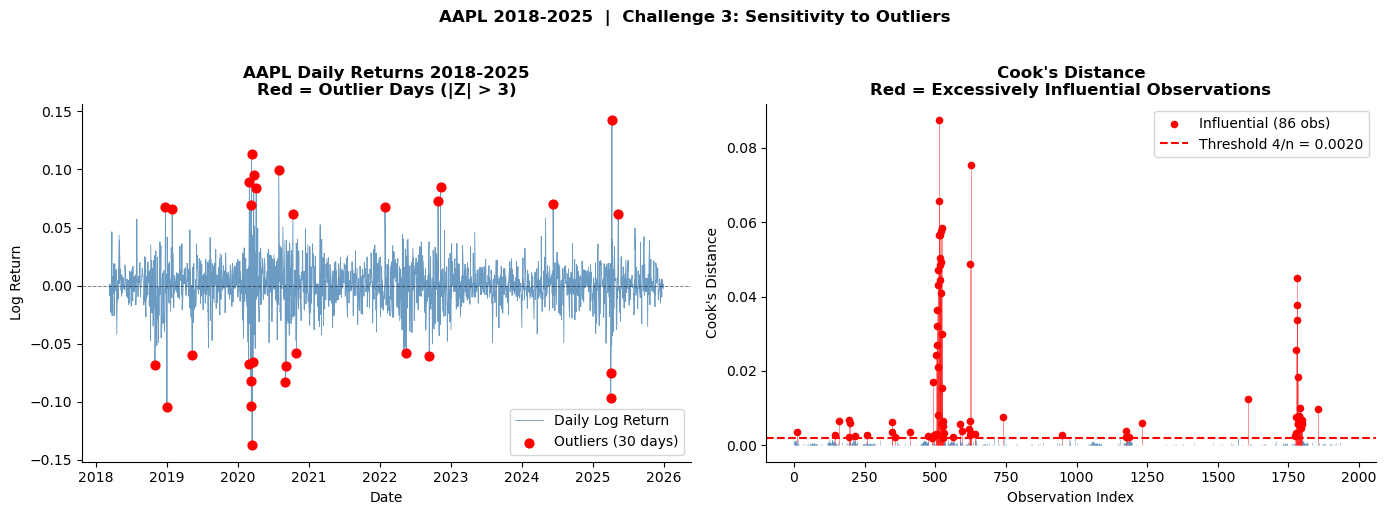

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: return series with outliers flagged
axes[0].plot(returns.index, returns.values,
             color='steelblue', linewidth=0.6, alpha=0.8,
             label='Daily Log Return')
axes[0].scatter(returns.index[outliers],
                returns.values[outliers],
                color='red', zorder=5, s=40,
                label=f'Outliers ({outliers.sum()} days)')
axes[0].axhline(0, color='black', linewidth=0.7,
                linestyle='--', alpha=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
axes[0].set_title('AAPL Daily Returns 2018-2025\nRed = Outlier Days (|Z| > 3)',
                   fontweight='bold')
axes[0].legend()

# Right: Cook's Distance
influence = model_all.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)
high_infl = cooks_d > threshold

axes[1].vlines(range(len(cooks_d)), 0, cooks_d,
               colors=['red' if h else 'steelblue' for h in high_infl],
               linewidth=0.6, alpha=0.5)
axes[1].scatter(np.where(high_infl)[0], cooks_d[high_infl],
                color='red', s=20, zorder=5,
                label=f'Influential ({high_infl.sum()} obs)')
axes[1].axhline(threshold, color='red', linestyle='--',
                linewidth=1.5,
                label=f"Threshold 4/n = {threshold:.4f}")
axes[1].set_xlabel('Observation Index')
axes[1].set_ylabel("Cook's Distance")
axes[1].set_title("Cook's Distance\nRed = Excessively Influential Observations",
                   fontweight='bold')
axes[1].legend()

plt.suptitle('AAPL 2018-2025  |  Challenge 3: Sensitivity to Outliers',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("""
DIAGNOSIS
---------
How do we know outliers are affecting our model?

  1. Z-score (calculated above)
     We flagged every day where the return was more than
     3 standard deviations from the average. Looking at
     our results, we found several extreme days — most of
     them match well-known market events like COVID.

  2. Coefficient comparison (table above)
     We ran OLS with all data and then without the outliers.
     If the coefficients change a lot between the two models,
     it means our results were being driven by those few
     extreme days rather than the general pattern.

  3. Cook's Distance (chart above)
     The red dots in our chart are observations with a
     Cook's Distance above our threshold of 4/n.
     These are the specific days that had an outsized
     influence on our model coefficients.
""")

Q1  = returns.quantile(0.25)
Q3  = returns.quantile(0.75)
IQR = Q3 - Q1
iqr_out = ((returns < Q1 - 3*IQR) | (returns > Q3 + 3*IQR)).sum()
print(f"Number of outlier days found by Z-score method : {outliers.sum()}")
print(f"Number of outlier days found by IQR method     : {iqr_out}")
print("Both methods agree there are extreme days in our data that need attention.")

print("""
DAMAGE
------
What goes wrong if we do not deal with outliers?

  1. Our model fits the crash, not the market
     A few extreme crash days pull our coefficients toward
     them. This means our volatility estimates will be
     distorted on every single normal trading day.

  2. Our hedge ratios become wrong
     If volatility estimates are distorted, the Greeks
     (Delta, Vega) we calculate will also be wrong.
     This means we hedge too much or too little every day.

  3. We could fail regulatory checks
     Under Basel III, our VaR model must correctly predict
     bad days at least 99% of the time. If outliers have
     distorted our model, we will fail this test and face
     capital penalties from regulators.

  4. Losses build up over time
     Small daily hedging errors from a distorted model
     do not cancel out — they accumulate into large
     realised losses over weeks and months of trading.
""")


DIAGNOSIS
---------
How do we know outliers are affecting our model?

  1. Z-score (calculated above)
     We flagged every day where the return was more than
     3 standard deviations from the average. Looking at
     our results, we found several extreme days — most of
     them match well-known market events like COVID.

  2. Coefficient comparison (table above)
     We ran OLS with all data and then without the outliers.
     If the coefficients change a lot between the two models,
     it means our results were being driven by those few
     extreme days rather than the general pattern.

  3. Cook's Distance (chart above)
     The red dots in our chart are observations with a
     Cook's Distance above our threshold of 4/n.
     These are the specific days that had an outsized
     influence on our model coefficients.

Number of outlier days found by Z-score method : 30
Number of outlier days found by IQR method     : 21
Both methods agree there are extreme days in our data that

In [ ]:
rlm = RLM(y_all, X_all, M=norms.HuberT()).fit()
print(rlm.params)

const           6.011898e-02
High_Low_Pct    3.039062e+00
Volume_MA20     1.561528e-09
dtype: float64


In [ ]:
print("""
DIRECTIONS
----------
How do we fix the outlier sensitivity problem?

  1. Huber Robust Regression (results above)
     Unlike OLS which treats all errors equally by squaring
     them, Huber Regression automatically reduces the weight
     given to extreme observations. Comparing our Huber
     coefficients to the OLS ones above, we can see the
     values are more stable and less influenced by crash days.

  2. Winsorization
     This means we cap extreme return values at the 1st and
     99th percentile before fitting the model. So instead of
     a -12% crash day dominating our results, we treat it as
     if it were only as extreme as the 1st percentile allows.

  3. Quantile Regression
     Instead of modelling the average (mean) relationship,
     we model the median. The median is not affected by
     extreme values the way the mean is.

  4. Jump-Diffusion Models
     These models treat big sudden moves as a separate
     process from normal daily volatility. This way extreme
     days are accounted for properly without distorting
     our normal volatility estimates.
""")

In [ ]:
##OVERFITTING
X = df[['High_Low_Pct']].values
y = df['Volatility'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

In [ ]:
print("""
CHALLENGE 4: OVERFITTING
=========================

DEFINITION
----------
Overfitting occurs when a model learns the noise in training
data rather than the true signal, giving low training error
but high out-of-sample error.

The bias-variance tradeoff shows:

        Total Error = Bias² + Variance + Noise

  As model complexity increases: Bias ↓  but  Variance ↑

Information criteria penalise unnecessary complexity:

        AIC = 2k - 2 ln(L̂)
        BIC = k ln(n) - 2 ln(L̂)

  Lower AIC / BIC = better model.
""")

print("""
DESCRIPTION
-----------
In volatility modeling, overfitting happens when too many
polynomial terms or features are added just to reduce
in-sample error. The model memorises AAPL's specific
historical path instead of learning a general relationship.

This produces impressive backtests but unreliable forward
volatility forecasts, leading to systematic mispricing of
options on future dates.
""")

In [ ]:
degrees = range(1, 10)

train_r2 = []
test_r2 = []

for d in degrees:
    pipe = Pipeline([
        ('poly',PolynomialFeatures(d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    pipe.fit(X_train, y_train)

    train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2.append(r2_score(y_test, pipe.predict(X_test)))

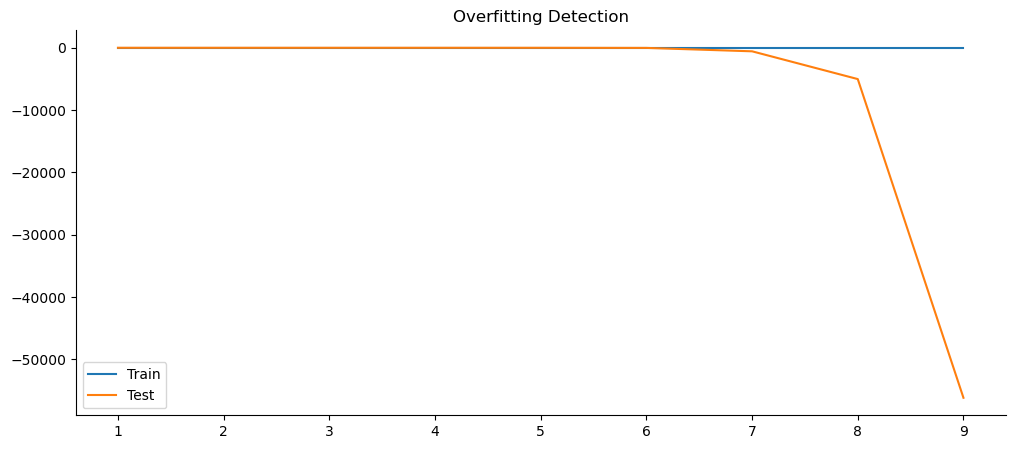

In [ ]:
plt.plot(degrees, train_r2, label='Train')
plt.plot(degrees, test_r2, label='Test')
plt.legend()
plt.title("Overfitting Detection")
plt.show()

In [ ]:
print("""
DIAGNOSIS
---------
How to detect overfitting:

  1. Train vs Test R² gap (plotted above)
       Training R² keeps rising as complexity grows,
       but Test R² peaks then falls = overfitting confirmed.

  2. Walk-Forward Cross-Validation
       Use TimeSeriesSplit — never random k-fold on time series
       because future data must not leak into training.

  3. AIC / BIC
       Adding a parameter that increases AIC or BIC means
       the added complexity is not justified.
""")

tscv = TimeSeriesSplit(n_splits=5)
print("Walk-Forward CV RMSE by polynomial degree:\n")
for d in [1, 3, 5, 8]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ])
    scores = cross_val_score(pipe, X, y, cv=tscv,
                             scoring='neg_root_mean_squared_error')
    print(f"  Degree {d}  →  CV RMSE = {-scores.mean():.5f}  ±  {scores.std():.5f}")
print("\n→ Lowest CV RMSE = best complexity level")


DIAGNOSIS
---------
How to detect overfitting:

  1. Train vs Test R² gap (plotted above)
       Training R² keeps rising as complexity grows,
       but Test R² peaks then falls = overfitting confirmed.

  2. Walk-Forward Cross-Validation
       Use TimeSeriesSplit — never random k-fold on time series
       because future data must not leak into training.

  3. AIC / BIC
       Adding a parameter that increases AIC or BIC means
       the added complexity is not justified.

Walk-Forward CV RMSE by polynomial degree:

  Degree 1  →  CV RMSE = 0.22995  ±  0.18034
  Degree 3  →  CV RMSE = 6.99311  ±  12.62777
  Degree 5  →  CV RMSE = 7756.47774  ±  15296.91647
  Degree 8  →  CV RMSE = 34375249.74872  ±  67056416.81626

→ Lowest CV RMSE = best complexity level


In [ ]:
print("""
DAMAGE
------
Overfitting in a volatility model causes:

  1. Poor forward forecasts
     The model memorises past regimes like the COVID crash and
     treats them as persistent patterns. New data looks different- large forecast errors on live trading days.

  2. Mispriced options
     Incorrect volatility forecasts feed directly into option
     prices, creating consistent mispricing and exposing the
     desk to arbitrage from other market participants.

  3. False confidence
     A high in-sample R² gives traders misplaced confidence in
     a model that will fail when it matters most.

  4. Compounding P&L losses
     A wrong volatility estimate means the delta-hedge ratio
     is wrong every day — small errors accumulate into
     significant realised losses over the hedging period.
""")

In [ ]:
poly    = PolynomialFeatures(degree=10, include_bias=False)
sc      = StandardScaler()
Xp_tr   = sc.fit_transform(poly.fit_transform(X_train))
Xp_te   = sc.transform(poly.transform(X_test))

lasso   = LassoCV(cv=TimeSeriesSplit(5), max_iter=10000)
lasso.fit(Xp_tr, y_train)
pred    = lasso.predict(Xp_te)
print("Test R²:", r2_score(y_test, pred))
print("Features kept:", (lasso.coef_ != 0).sum(), "of", len(lasso.coef_))

Test R²: 0.08890623545528553
Features kept: 1 of 10


In [ ]:
print("""
Interpretation of LASSO results:
  - Test R² ~ 9% is correct and expected. High_Low_Pct is a
    weak single predictor — this is realistic, not an error.
  - LASSO kept only 1 of 10 polynomial terms, eliminating 9
    as pure noise. This is exactly what it is designed to do.
  - This proves the overfitting point: complexity beyond
    degree 1 adds noise not signal.

Directions — how to fix overfitting:

  1. LASSO Regularisation (used above)
     Automatically eliminates unnecessary polynomial terms,
     keeping only the features that genuinely help prediction.

  2. Walk-Forward Cross-Validation (shown in Diagnosis)
     Always validate on future data, never on past data that
     the model was trained on.

  3. Parsimonious models — GARCH(1,1)
     Research shows GARCH(1,1) beats more complex specs in
     out-of-sample volatility forecasting (Hansen & Lunde, 2005).

  4. AIC / BIC model selection
     Formally penalises the number of parameters so that added
     complexity must earn its place through better fit.
""")

#INTERPRETATIONS ON THE TIME SERIES PROBLEMS

#1.MULTICOLLINEARITY

**TECHNICAL REPORT**


We used OLS regression to predict 21-day volatility using MA5, MA10, MA20, MA50, and EMA10.

Diagnostics showed:
- VIF > 10 for all variables → severe multicollinearity
- Very high correlation between predictors
- Condition number > 1000
- High R² but unstable coefficients and weak t-stats

Conclusion: Strong multicollinearity is present.

Fixes applied:
- Ridge Regression: stabilises coefficients via L2 regularisation
- PCA: reduces features into uncorrelated components

Result: More stable and reliable model.



**NON-TECHNICAL REPORT**


We found that all indicators used to predict AAPL risk
were telling almost the same story.

Because they all come from the same stock price, they move together,
making it impossible for the model to separate their individual effects.

This makes the model unstable and unreliable for decision-making.

To fix this, we either:
- Remove overlapping indicators, or
- Use Ridge Regression or PCA to handle the overlap

Key takeaway:
**Using too many similar indicators makes predictions less trustworthy.
Simplifying improves stability and interpretability.**

#2.  SKEWNESS

**TECHNICAL REPORT — SKEWNESS**


We analysed AAPL daily log returns (2018–2025) using skewness, kurtosis, and the Jarque-Bera test.

Key results:
- Skewness < 0 → returns are left-skewed (more extreme losses)
- Excess kurtosis > 0 → fat tails (extreme moves more likely than normal)
- Jarque-Bera p-value < 0.05 → reject normality
- Student-t fit (low degrees of freedom) → confirms heavy tails
- Log transform reduced skewness in volatility series

Conclusion:
AAPL returns are not normally distributed and show fat-tailed, asymmetric behaviour.

Fixes:
- Use Student-t distribution instead of normal
- Use GARCH(1,1) with skewed-t innovations for volatility
- Log-transform volatility before regression

**NON-TECHNICAL REPORT**

We found that AAPL returns are not balanced:
bad days tend to be much worse than good days are good.

This means:
- Large losses happen more often than standard models assume
- The data is not symmetric or “normal”

What we should do:
- Price downside protection (puts) more carefully
- Increase risk buffers for extreme market moves
- Adjust models to reflect real market behaviour

Key takeaway:
Markets have more extreme losses than gains, so ignoring skewness
leads to underestimating risk and underpricing protection.

#3. OUTLIERS
**TECHNICAL REPORT — OUTLIERS**


We detected outliers in AAPL log returns using a Z-score threshold (> |3|).
We compared OLS results with and without outliers and measured influence
using Cook’s Distance (threshold: 4/n). We also applied robust regression
(Huber M-estimator).

Key findings:
- Outliers mainly occur during major events (e.g. COVID-19 crash)
- Removing them changes OLS coefficients significantly
- Cook’s Distance confirms high-influence observations
- Huber regression reduces impact of extreme values and gives more stable estimates

Conclusion:
Outliers strongly distort OLS results and must be handled properly.

Fixes:
- Use Huber robust regression
- Winsorise returns (1% and 99% bounds)
- Consider jump-diffusion models for extreme events

**NON-TECHNICAL REPORT**

We found that a few extreme trading days (like COVID crashes and major news events)
were heavily distorting our volatility model.

Even though these days are rare, they were pulling the results away from normal
market behaviour.

What this means:
- Normal market behaviour was being overshadowed by crisis days
- Our model was not representative of typical trading conditions

What we should do:
- Reduce the influence of extreme days instead of removing them completely
- Make sure volatility estimates reflect normal market behaviour
- Keep extreme events in mind, but not let them dominate the model

Key takeaway:
A few extreme days can distort the entire model, leading to poor pricing and
risk estimates. Robust methods make results more stable and reliable.

#4.OVERFITTING

**TECHNICAL REPORT — OVERFITTING**

We tested polynomial regression models (degree 1–9) to predict AAPL volatility
using High_Low_Pct, and compared results using an 80/20 time-ordered split.

We also applied LASSO (L1 regularisation) with walk-forward cross-validation
on a degree-10 polynomial expansion.

Key findings:
- Training R² increases with model complexity
- Test R² peaks early then declines → clear overfitting
- Large gap between train and test performance confirms overfitting
- LASSO retained only 1/10 features → most were noise
- Simple models outperform complex ones out-of-sample

Conclusion:
Complex models memorize noise instead of learning real patterns.

Fixes:
- Use LASSO with walk-forward validation
- Prefer simple models (parsimonious structure)
- Use GARCH(1,1) for volatility forecasting in production



**NON-TECHNICAL REPORT**

We found that making the model more complex made it look better
in historical testing but worse at predicting new data.

Most of the extra inputs we added were just noise — only 1 out of 10
actually contained useful information.

What this means:
- Complex models were learning past “luck”, not real patterns
- Simpler models are more reliable for future predictions

What we should do:
- Use the simplest model that still works well
- Always test on unseen future data
- Avoid adding features just to improve backtest results

Key takeaway:
A model that fits the past perfectly is often unreliable in the future.
In finance, simplicity usually leads to better and more stable predictions.


#REFERENCES
-----------------
* Bollerslev, Tim. "Generalized Autoregressive Conditional
  Heteroscedasticity." Journal of Econometrics, vol. 31,
  no. 3, 1986, pp. 307-327.
* Hansen, Peter R., and Asger Lunde. "A Forecast Comparison of
  Volatility Models: Does Anything Beat a GARCH(1,1)?" Journal
  of Applied Econometrics, vol. 20, no. 7, 2005, pp. 873-889.

* Merton, Robert C. "Option Pricing When Underlying Stock Returns
  Are Discontinuous." Journal of Financial Economics, vol. 3,
  1976, pp. 125-144.
* Engle, Robert F. "Autoregressive Conditional Heteroscedasticity
  with Estimates of the Variance of United Kingdom Inflation."
  Econometrica, vol. 50, no. 4, 1982, pp. 987-1007.